# OPCal image processing - caiman implementation

### Overview

This file runs CaImAn CNMF on OPC culture calcium-imaging movies to identify cell ROIs

### Set video path

In [ ]:
video_path = r'../data/RawData/20250409_3_Glut_1mM_TIF_VIDEO.tif'

### Imports and general setup

In [ ]:
# --- Debug-mode toggles (set True to capture per-stage snapshots for cnmf_viewer.py) ---
DEBUG_FIT = False
DEBUG_REFIT = False

if DEBUG_FIT or DEBUG_REFIT:
    import sys
    sys.path.insert(0, '../cnmf_toolkit')
    from instrumented_cnmf import CNMF, debug_tracker
else:
    from caiman.source_extraction.cnmf.cnmf import CNMF
    debug_tracker = None  # not used in non-debug mode

def _set_debug(phase, enabled):
    """Helper: switch the tracker phase + enable/disable. No-op in non-debug mode."""
    if debug_tracker is None:
        return
    debug_tracker.set_phase(phase)
    if enabled:
        debug_tracker.enable()
    else:
        debug_tracker.disable()

# --- Other CaImAn imports preserved from the original cell ---
import bokeh.plotting as bpl
import datetime
import glob
import holoviews as hv
from IPython import get_ipython
import logging
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import psutil
from pathlib import Path
import tifffile as tiff
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2

try:
    cv2.setNumThreads(0)
except():
    pass

try:
    if __IPYTHON__:
        get_ipython().run_line_magic('load_ext', 'autoreload')
        get_ipython().run_line_magic('autoreload', '2')
except NameError:
    pass

import caiman as cm
from caiman.motion_correction import MotionCorrect
from caiman.source_extraction.cnmf import cnmf, params
from caiman.utils.utils import download_demo
from caiman.utils.visualization import plot_contours, nb_view_patches, nb_plot_contour
from caiman.utils.visualization import nb_view_quilt

bpl.output_notebook()
hv.notebook_extension('bokeh')

# set up logging
logfile = None # Replace with a path if you want to log to a file
logger = logging.getLogger('caiman')
# Set to logging.INFO if you want much output, potentially much more output
logger.setLevel(logging.WARNING)
logfmt = logging.Formatter('%(relativeCreated)12d [%(filename)s:%(funcName)20s():%(lineno)s] [%(process)d] %(message)s')
if logfile is not None:
    handler = logging.FileHandler(logfile)
else:
    handler = logging.StreamHandler()
handler.setFormatter(logfmt)
logger.addHandler(handler)

# set env variables
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"

### Visualize data

Generates and plots the maximum intensity projection and local correlation image for an initial inspection of the calcium imaging data.

100%|██████████| 1/1 [00:01<00:00,  1.03s/it]


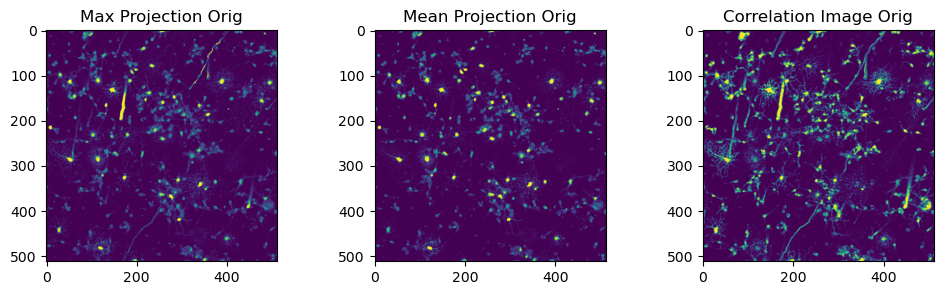

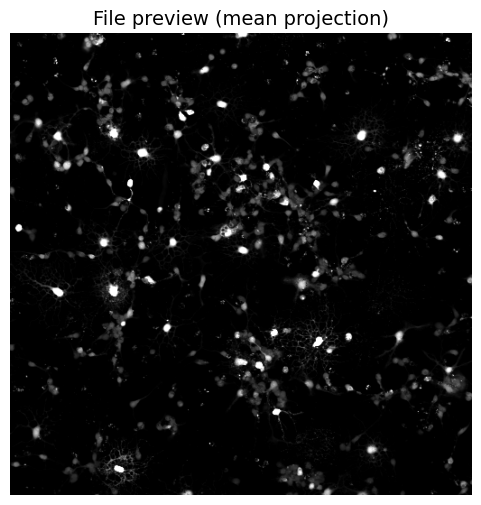

In [3]:
movie = cm.load_movie_chain([video_path])

max_projection_orig = np.max(movie, axis=0)
mean_projection = np.mean(movie, axis=0)
correlation_image_orig = cm.local_correlations(movie, swap_dim=False)
correlation_image_orig[np.isnan(correlation_image_orig)] = 0 # get rid of NaNs, if they exist

f, (ax_max, ax_mean, ax_corr) = plt.subplots(1,3,figsize=(12,3))
ax_max.imshow(max_projection_orig,
              cmap='viridis',
              vmin=np.percentile(np.ravel(max_projection_orig),50),
              vmax=np.percentile(np.ravel(max_projection_orig),99.5))
ax_max.set_title("Max Projection Orig", fontsize=12)

ax_mean.imshow(mean_projection,
              cmap='viridis',
              vmin=np.percentile(np.ravel(mean_projection),50),
              vmax=np.percentile(np.ravel(mean_projection),99.5))
ax_mean.set_title("Mean Projection Orig", fontsize=12)

ax_corr.imshow(correlation_image_orig,
               cmap='viridis',
               vmin=np.percentile(np.ravel(correlation_image_orig),50),
               vmax=np.percentile(np.ravel(correlation_image_orig),99.5))
ax_corr.set_title('Correlation Image Orig', fontsize=12)

#save mean projection for later
vmin = np.percentile(mean_projection, 50)
vmax = np.percentile(mean_projection, 99.5)
mean_proj_norm = np.clip((mean_projection - vmin) / (vmax - vmin), 0, 1)

#File preview
plt.figure(figsize=(6, 6))
plt.imshow(mean_proj_norm, cmap='gray')
plt.title("File preview (mean projection)", fontsize=14)
plt.axis('off')
plt.show()

### Set initial parameters

In [ ]:
### parameters explanation - https://caiman.readthedocs.io/en/latest/Getting_Started.html ###
# general dataset-dependent parameters
fr = 1.08                               # imaging rate in frames per second                                                     ### User input ###
decay_time = 20                         # length of a typical transient in seconds 
dxy = (1.243, 1.243)                    # spatial resolution in x and y in (um per pixel)                                       ### User input ###
cell_diameter =10                       # in microns                                                                            ### User input ###
d_px = int(cell_diameter // dxy[0])     # convert microns ti pixels

# CNMF parameters for source extraction and deconvolution
p = 0                                   # order of the autoregressive system (set p=2 if there is visible rise time in data)   
gnb = 2                                 # number of global background components (set to 1 or 2)    
merge_thr = 0.2                         # merging threshold, max correlation allowed    
bas_nonneg = True                       # enforce nonnegativity constraint on calcium traces (technically on baseline)
rf = int(3*d_px)                        # half-size of the patches in pixels (patch width is rf*2 + 1)  
stride_cnmf = int(d_px)                 # amount of overlap between the patches in pixels (overlap is stride_cnmf+1)    
K = 4                                   # number of components per patch                                                        ### User input ###   
gSig = np.array([0.5*d_px, 0.5*d_px])   # expected half-width of neurons in pixels (Gaussian kernel standard deviation) 
gSiz = 2*gSig + 1                       # Gaussian kernel width and hight
method_init = 'greedy_roi'              # initialization method (if analyzing dendritic data see demo_dendritic.ipynb)  
ssub = 1                                # spatial subsampling during initialization     
tsub = 1                                # temporal subsampling during intialization     

# parameters for component evaluation   
min_SNR = 2.0               # signal to noise ratio for accepting a component
rval_thr = 0.85             # space correlation threshold for accepting a component

# CNN-based component classifier (currently disabled — uncomment all 4 lines below to enable)
# cnn_thr = 0.99              # threshold for CNN based classifier    
# cnn_lowest = 0.1            # neurons with cnn probability lower than this value are rejected

# parameters dictionary
parameter_dict = {'fnames': video_path,
                  'fr': fr,
                  'dxy': dxy,
                  'decay_time': decay_time,
                  'p': p,
                  'nb': gnb,
                  'rf': rf,
                  'K': K,
                  'gSig': gSig,
                  'gSiz': gSiz,
                  'stride': stride_cnmf,
                  'method_init': method_init,
                  'rolling_sum': True,
                  'only_init': True,
                  'ssub': ssub,
                  'tsub': tsub,
                  'merge_thr': merge_thr,
                  'bas_nonneg': bas_nonneg,
                  'min_SNR': min_SNR,
                  'rval_thr': rval_thr,
                  'use_cnn': False,
                  # 'min_cnn_thr': cnn_thr,
                  # 'cnn_lowest': cnn_lowest,
                  }

parameters = params.CNMFParams(params_dict=parameter_dict) # CNMFParams is the parameters class

### Set up multicore processing

Automatically configures parallel processing using available CPU cores to speed up CNMF fitting.

In [5]:
print(f"You have {psutil.cpu_count()} CPUs available in your current environment")
num_processors_to_use = None

if 'cluster' in locals():  # 'locals' contains list of current local variables
    print('Closing previous cluster')
    cm.stop_server(dview=cluster)
print("Setting up new cluster")
_, cluster, n_processes = cm.cluster.setup_cluster(backend='multiprocessing',
                                                   n_processes=num_processors_to_use,
                                                   ignore_preexisting=False)
print(f"Successfully initilialized multicore processing with a pool of {n_processes} CPU cores")

You have 22 CPUs available in your current environment
Setting up new cluster
Successfully initilialized multicore processing with a pool of 21 CPU cores


### Creating and accessing memory mapped files

Converts the TIFF video to a memory-mapped format for efficient reading.

In [6]:
border_to_0 = 0 # number of pixels to exclude from the boundaries
mc_memmapped_fname = cm.save_memmap([video_path], base_name='memmap_',
                                     order='C', border_to_0=0, dview=cluster)

       43268 [paths.py:         get_tempdir():46] [31604] Default temporary dir C:\Users\lotan\caiman_data\temp does not exist, creating


In [7]:
Yr, dims, num_frames = cm.load_memmap(mc_memmapped_fname)
images = np.reshape(Yr.T, [num_frames] + list(dims), order='F') #reshape frames in standard 3d format (T x X x Y)



In [8]:
cm.stop_server(dview=cluster)
_, cluster, n_processes = cm.cluster.setup_cluster(backend='multiprocessing',
                                                   n_processes=num_processors_to_use,
                                                   single_thread=False)

### cNMF segmentation

Initializes patches based on defined stride and size.

Here the user can inspect the spatial parameters, count number of cells in a patch and change K accordin to thr culture density

In [ ]:
### Inspection of spatial parameters

cnmf_model = CNMF(n_processes,
                  params=parameters,
                  dview=cluster)

### Here the user is inspecting the spatial parameters  and can change it if needed ###
### Let's evaluate our spatial parameters using the quilt plot

### Is the patch width at least three times the width of a neuron? Yes
### Do individual neurons fit in the overlap region (stride)? Yes.
### When in interactive mode, you can zoom and inspect the average width of each neuron in pixels. Is gSig about half that? Yes. Each neuron is about 6-8 pixels wide, and gSig is 4.
### For K: how many neurons are in each patch? Remember you want an upper bound, not an average. The current value of 4 seems good.

### Keep in mind that there is typically no perfect set of parameter values: ultimately the only way to know if a set of parameters is good is to fit the model and see how well it performs. Sometimes you just have to iteratively search a bit in parameter space.


# calculate stride and overlap from parameters
cnmf_patch_width = cnmf_model.params.patch['rf']*2 + 1
cnmf_patch_overlap = cnmf_model.params.patch['stride'] + 1
cnmf_patch_stride = cnmf_patch_width - cnmf_patch_overlap
print(f'Patch width: {cnmf_patch_width} , Stride: {cnmf_patch_stride}, Overlap: {cnmf_patch_overlap}');

# plot the patches
patch_ax = nb_view_quilt(mean_proj_norm,
                      cnmf_model.params.patch['rf'],
                      cnmf_model.params.patch['stride'])

#### Initial detection

Performs source extraction

In [ ]:
%%time
_set_debug('fit', DEBUG_FIT)
cnmf_model.fit(images)

In [11]:
cnmf_model.estimates.plot_contours_nb(img=max_projection_orig)

In [ ]:
%%time
_set_debug('refit', DEBUG_REFIT)
cnmf_refit = cnmf_model.refit(images, dview=cluster)

In [13]:
cnmf_refit.estimates.plot_contours_nb(img=max_projection_orig)